# Notebook 00 — Data Exploration
**CICIoT2023 dataset** | 8-class IoT attack classification | University of Deusto — Advanced ML

## 1. Setup & Imports

Libraries, constants, and the label mapping from 34 fine-grained attack types to the 8 category classes used in this project.

In [1]:
import glob, os, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED            = 42
DATA_DIR        = '../data/'
GLOB_PATTERN    = os.path.join(DATA_DIR, 'part-*.csv')
SAMPLE_PER_FILE = 3000

LABEL_MAP = {
    'DDoS-ICMP_Flood':'DDoS','DDoS-UDP_Flood':'DDoS','DDoS-TCP_Flood':'DDoS',
    'DDoS-PSHACK_Flood':'DDoS','DDoS-SYN_Flood':'DDoS','DDoS-RSTFINFlood':'DDoS',
    'DDoS-SynonymousIP_Flood':'DDoS','DDoS-ACK_Fragmentation':'DDoS',
    'DDoS-UDP_Fragmentation':'DDoS','DDoS-ICMP_Fragmentation':'DDoS',
    'DDoS-SlowLoris':'DDoS','DDoS-HTTP_Flood':'DDoS',
    'DoS-UDP_Flood':'DoS','DoS-SYN_Flood':'DoS','DoS-TCP_Flood':'DoS','DoS-HTTP_Flood':'DoS',
    'Recon-PingSweep':'Recon','Recon-OSScan':'Recon','Recon-PortScan':'Recon',
    'VulnerabilityScan':'Recon','Recon-HostDiscovery':'Recon',
    'SqlInjection':'Web-based','CommandInjection':'Web-based','Backdoor_Malware':'Web-based',
    'Uploading_Attack':'Web-based','XSS':'Web-based','BrowserHijacking':'Web-based',
    'DictionaryBruteForce':'BruteForce',
    'DNS_Spoofing':'Spoofing','MITM-ArpSpoofing':'Spoofing',
    'Mirai-greIp':'Mirai','Mirai-greEth':'Mirai','Mirai-udpplain':'Mirai',
    'BenignTraffic':'Benign',
}

KEY_FEATURES  = ['Header_Length', 'Rate', 'fin_flag_number', 'IAT', 'Tot size', 'Number']
CONSTANT_COLS = ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC']

## 2. Data Loading

Stratified sampling: 3,000 rows per CSV file × 169 files = ~507K rows. Sampling uniformly across files preserves temporal and attack-type coverage without loading the full 46.7M rows (~20 GB) into memory. The `category` column is created via `LABEL_MAP`.

In [2]:
files  = sorted(glob.glob(GLOB_PATTERN))
chunks = []
for f in files:
    chunk = pd.read_csv(f, nrows=SAMPLE_PER_FILE)
    chunks.append(chunk)
    del chunk

df = pd.concat(chunks, ignore_index=True)
del chunks

df['category'] = df['label'].map(LABEL_MAP)

mem_mb = df.memory_usage(deep=True).sum() / 1e6
print(f'Shape        : {df.shape}')
print(f'Memory       : {mem_mb:.1f} MB')
print(f'Files loaded : {len(files)}')
print(f'Categories   : {df["category"].nunique()} | Fine-grained labels: {df["label"].nunique()}')
print(f'Unmapped rows: {df["category"].isna().sum()}')

Shape        : (507000, 48)
Memory       : 253.7 MB
Files loaded : 169
Categories   : 8 | Fine-grained labels: 34
Unmapped rows: 18651


## 3. Class Distribution

The sampling strategy is uniform across files, so the resulting proportions reflect the **true class distribution** in the full dataset. DDoS dominates; Web-based and BruteForce are extreme minorities.

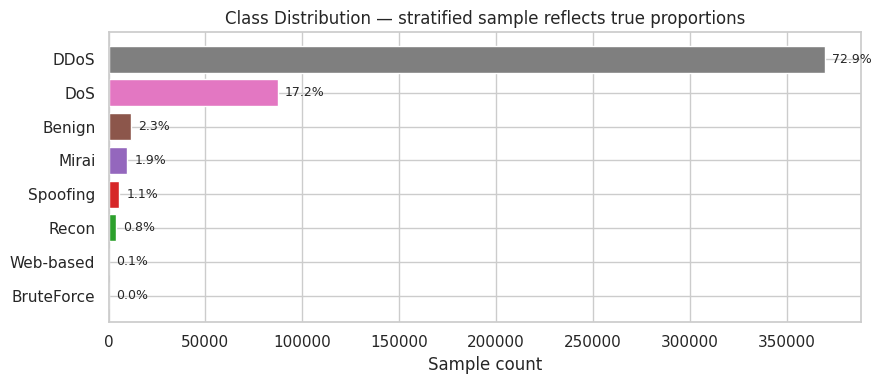


Imbalance ratio (max/min): 2385.9x
             count    pct
category                 
DDoS        369807  72.94
DoS          87404  17.24
Benign       11812   2.33
Mirai         9683   1.91
Spoofing      5447   1.07
Recon         3782   0.75
Web-based      259   0.05
BruteForce     155   0.03


In [3]:
cat_counts = df['category'].value_counts().sort_values(ascending=True)
cat_pct    = (cat_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(9, 4))
colors = sns.color_palette('tab10', len(cat_counts))
bars = ax.barh(cat_counts.index, cat_counts.values, color=colors)
for bar, pct in zip(bars, cat_pct.values):
    ax.text(bar.get_width() + cat_counts.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Sample count')
ax.set_title('Class Distribution — stratified sample reflects true proportions')
plt.tight_layout()
plt.show()

imbalance = cat_counts.max() / cat_counts.min()
print(f'\nImbalance ratio (max/min): {imbalance:.1f}x')
print(pd.DataFrame({'count': cat_counts, 'pct': cat_pct}).sort_values('count', ascending=False))

## 4. Data Quality

Checking for NaN values, Inf values, duplicates, and constant (zero-variance) columns. The NaN count comes from rows whose `label` value is not in `LABEL_MAP` — these are dropped in preprocessing. No imputation needed.

In [4]:
numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
nan_total     = df.isna().sum().sum()
inf_total     = np.isinf(df[numeric_cols]).sum().sum()
n_dupes       = df.duplicated().sum()
constant_cols = [c for c in numeric_cols if df[c].std() == 0]

print(f'NaN values     : {nan_total}')
print(f'Inf values     : {inf_total}')
print(f'Duplicate rows : {n_dupes:,} ({n_dupes / len(df) * 100:.2f}%)')
print(f'Constant cols  : {constant_cols}')

NaN values     : 18651
Inf values     : 0
Duplicate rows : 0 (0.00%)
Constant cols  : ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']


## 5. Basic Statistics

Descriptive statistics across all non-constant numeric features. Note the extreme `range` and `cv` (coefficient of variation) values — features like `Rate`, `Header_Length`, and `Drate` span several orders of magnitude, which rules out StandardScaler in favor of **RobustScaler**.

In [5]:
feature_cols  = [c for c in numeric_cols if c not in CONSTANT_COLS]
desc          = df[feature_cols].describe().T
desc['range'] = desc['max'] - desc['min']
desc['cv']    = df[feature_cols].std() / df[feature_cols].mean().abs()

desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'cv']].round(4)

,mean,std,min,25%,50%,75%,max,range,cv
flow_duration,5.641400e+00,2.481486e+02,0.0000,0.000000e+00,0.000000e+00,1.045000e-01,5.779187e+04,5.779187e+04,43.9871
Header_Length,7.668699e+04,4.659658e+05,0.0000,5.400000e+01,5.400000e+01,2.746375e+02,9.825656e+06,9.825656e+06,6.0762
Protocol Type,9.041300e+00,8.904300e+00,0.0000,6.000000e+00,6.000000e+00,1.396000e+01,4.700000e+01,4.700000e+01,0.9848
Duration,6.634330e+01,1.402570e+01,0.0000,6.400000e+01,6.400000e+01,6.400000e+01,2.550000e+02,2.550000e+02,0.2114
Rate,8.938349e+03,9.860133e+04,0.0000,2.094000e+00,1.577300e+01,1.183439e+02,8.388608e+06,8.388608e+06,11.0313
Srate,8.938349e+03,9.860133e+04,0.0000,2.094000e+00,1.577300e+01,1.183439e+02,8.388608e+06,8.388608e+06,11.0313
Drate,0.000000e+00,2.000000e-03,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,1.277000e+00,1.277000e+00,378.7904
fin_flag_number,8.720000e-02,2.822000e-01,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.2346
syn_flag_number,2.078000e-01,4.057000e-01,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.9526
rst_flag_number,9.120000e-02,2.879000e-01,0.0000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,3.1568


## 6. Outlier & Scale Analysis

Left: log1p-transformed boxplots of 6 key features confirm heavy-tailed distributions. Right: coefficient of variation per feature sorted — high CV features are highly variable relative to their mean, which is expected for network traffic metrics. StandardScaler would be distorted by these extremes; **RobustScaler** (IQR-based) is the appropriate choice.

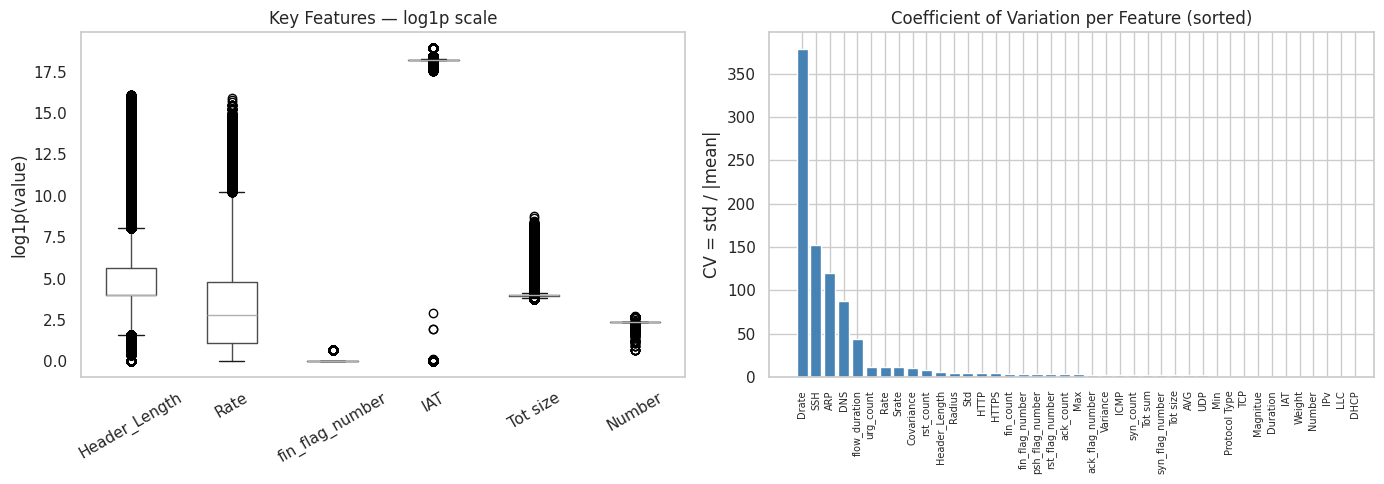

Top 5 highest-CV features:
Drate            378.790361
SSH              151.804150
ARP              120.352577
DNS               87.640364
flow_duration     43.987060


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: log1p boxplots of 6 key features
log_data = np.log1p(df[KEY_FEATURES].clip(lower=0))
log_data.boxplot(ax=axes[0], rot=30, grid=False)
axes[0].set_title('Key Features — log1p scale')
axes[0].set_ylabel('log1p(value)')

# Right: coefficient of variation, sorted
cv = (df[feature_cols].std() / df[feature_cols].mean().abs()).sort_values(ascending=False)
axes[1].bar(range(len(cv)), cv.values, color='steelblue')
axes[1].set_xticks(range(len(cv)))
axes[1].set_xticklabels(cv.index, rotation=90, fontsize=7)
axes[1].set_title('Coefficient of Variation per Feature (sorted)')
axes[1].set_ylabel('CV = std / |mean|')

plt.tight_layout()
plt.show()

print(f'Top 5 highest-CV features:\n{cv.head().to_string()}')

## 7. Correlation Analysis

Pearson correlation across all non-constant numeric features. Pairs with |r| > 0.95 are near-redundant. Tree-based models handle collinearity, but high correlation inflates dimensionality and can hurt interpretability. These pairs will be candidates for feature selection in the preprocessing notebook.

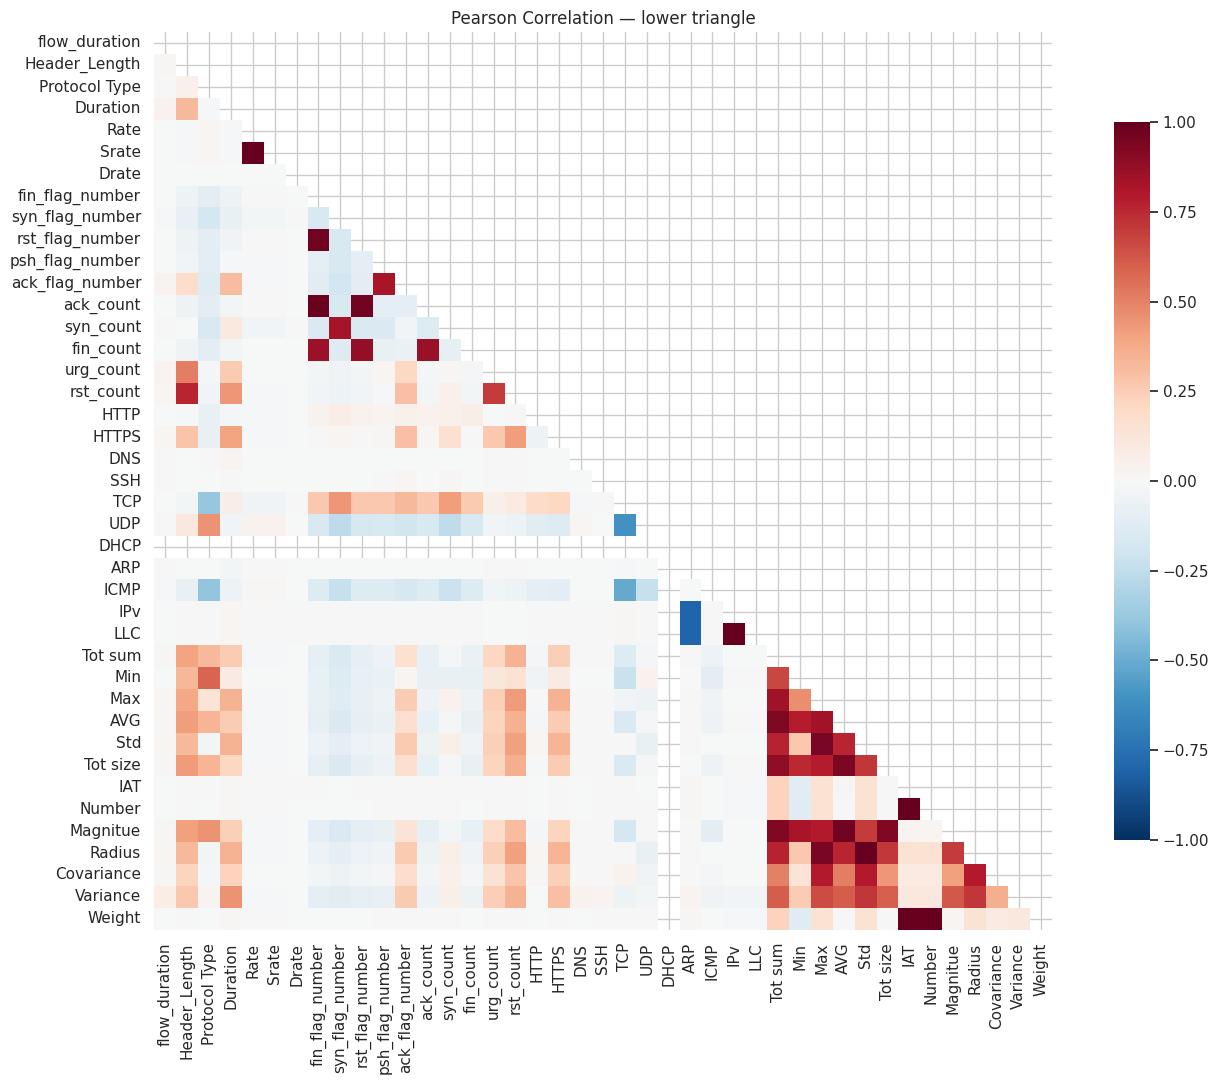


Pairs with |r| > 0.95  (12 total):
      feature_a       feature_b        r
          Srate            Rate 1.000000
            LLC             IPv 1.000000
         Radius             Std 0.999969
         Weight          Number 0.999622
         Weight             IAT 0.996699
         Number             IAT 0.995409
      ack_count fin_flag_number 0.985785
rst_flag_number fin_flag_number 0.975677
       Magnitue             AVG 0.968647
      ack_count rst_flag_number 0.962012
            Std             Max 0.952305
         Radius             Max 0.952281


In [7]:
corr = df[feature_cols].corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0, annot=False, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation — lower triangle')
plt.tight_layout()
plt.show()

pairs = (
    corr.where(~mask)
        .stack()
        .reset_index()
        .rename(columns={'level_0': 'feature_a', 'level_1': 'feature_b', 0: 'r'})
)
high = pairs[pairs['r'].abs() > 0.95].sort_values('r', key=abs, ascending=False)
print(f'\nPairs with |r| > 0.95  ({len(high)} total):')
print(high.to_string(index=False))

## 8. Feature Distributions by Category

4 features with plausible discriminative power, grouped by attack category. `Rate` and `Header_Length` show the clearest median separation between classes. `fin_flag_number` is near-zero for most categories but elevated for TCP-based attacks. `IAT` overlaps substantially — useful in combination, not alone.

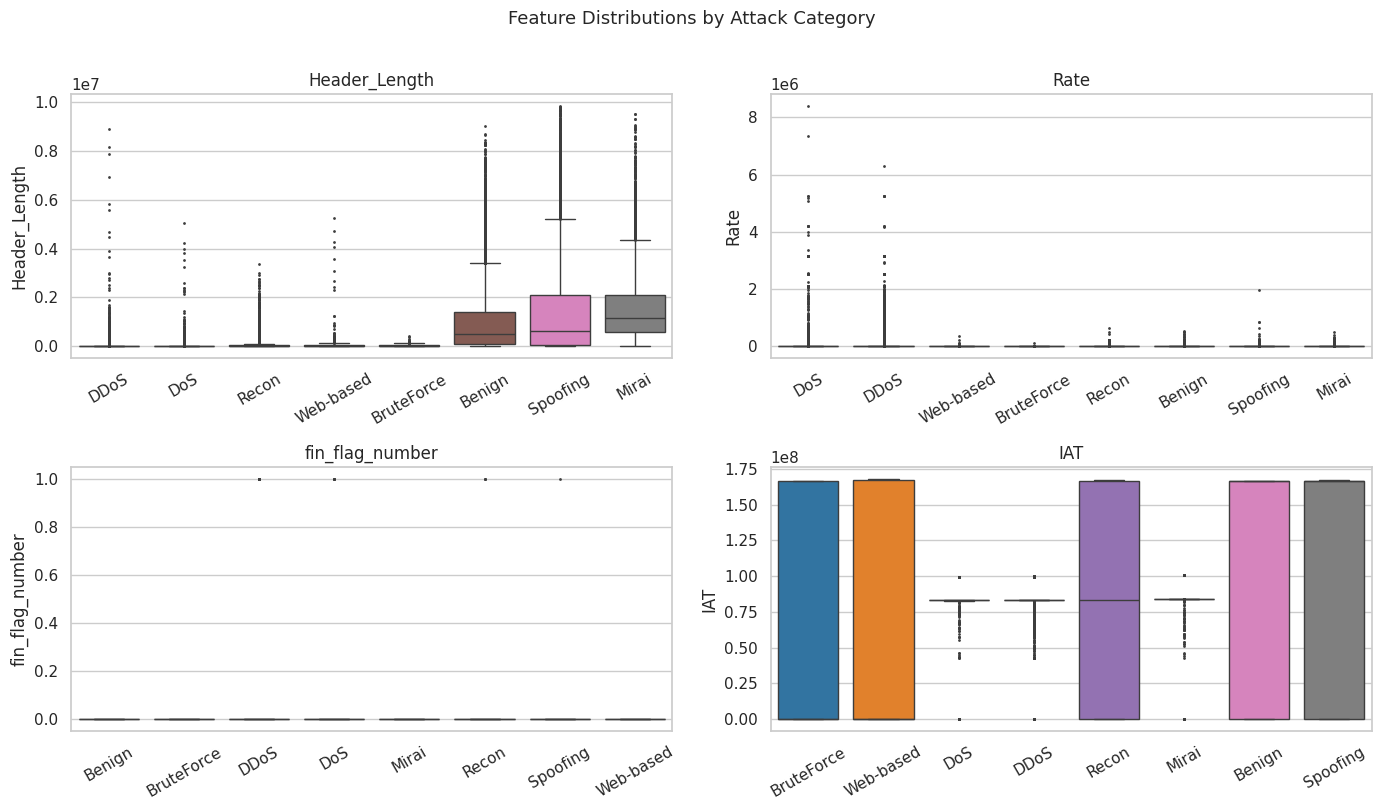

In [8]:
DISCRIM = ['Header_Length', 'Rate', 'fin_flag_number', 'IAT']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), DISCRIM):
    order = df.groupby('category')[feat].median().sort_values().index
    sns.boxplot(data=df, x='category', y=feat, order=order,
                ax=ax, fliersize=1, palette='tab10')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Feature Distributions by Attack Category', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary

**Key findings from EDA:**

- **Dataset:** ~46.7M rows total; working sample of 507K (stratified, 3K/file) is representative.
- **Severe imbalance:** DDoS ~73%, BruteForce ~0.03%. Max/min ratio ≈ 2,400x in the sample (5,751x in the full dataset per the original paper). Any model trained without compensation will collapse to predicting the majority class.
- **Data quality:** No NaN/Inf in features. 18,651 unmapped rows (from the full label space) → drop in preprocessing. No constant-feature imputation needed.
- **Constant columns to drop:** `ece_flag_number`, `cwr_flag_number`, `Telnet`, `SMTP`, `IRC`, `DHCP` — zero variance, no signal.
- **Scale issue:** Features span several orders of magnitude with extreme outliers (CV > 10 for `Rate`, `Drate`). **RobustScaler** is the appropriate scaler; StandardScaler would be heavily distorted.
- **Highly correlated pairs:** Multiple pairs with |r| > 0.95 (e.g., `Rate`/`Srate` are nearly identical). These will be addressed in preprocessing via feature selection.
- **Discriminative signal confirmed:** `Rate`, `Header_Length`, and `fin_flag_number` show clear distributional differences across categories — the 8-class problem is tractable.

**Next:** Notebook 01 — Preprocessing (deduplication, constant column removal, scaling, label encoding, stratified 70/15/15 split, export to parquet).